In [ ]:
import torch
from torch.utils.data import Dataset, DataLoader
import numpy as np
import pandas as pd

class MNISTDataset(Dataset):
  def __init__(self, path):
    data = pd.read_csv(path, header=None).to_numpy()
    self.x = data[:, 1:]

  def __len__(self):
    return self.x.shape[0]

  def __getitem__(self, idx):
    xi = torch.tensor(self.x[idx], dtype=torch.float32)
    return xi

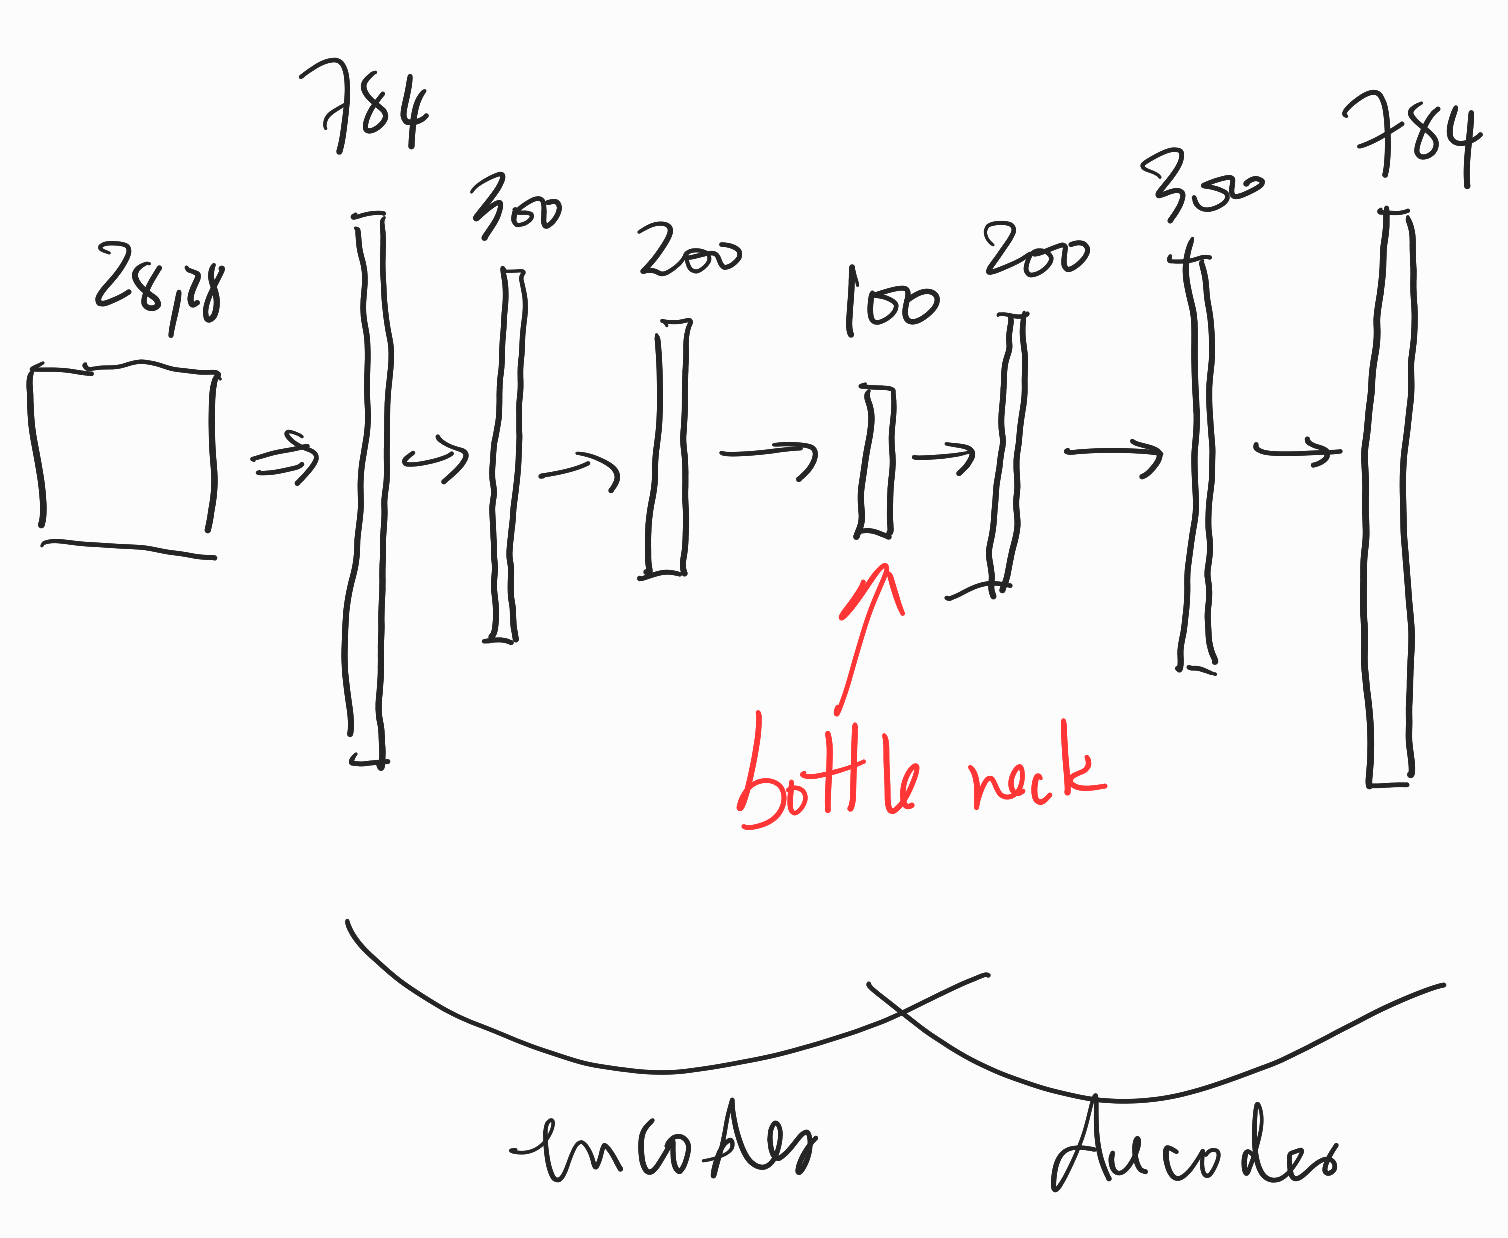

In [ ]:
import torch.nn as nn

class Encoder(nn.Module):
  def __init__(self):
    super().__init__()
    self.layers = nn.Sequential(
        nn.Linear(784, 300),
        nn.ReLU(),
        nn.Linear(300, 200),
        nn.ReLU(),
        nn.Linear(200, 100)
    )

  def forward(self, x):
    return self.layers(x)

class Decoder(nn.Module):
  def __init__(self):
    super().__init__()
    self.layers = nn.Sequential(
        nn.Linear(100, 200),
        nn.ReLU(),
        nn.Linear(200, 300),
        nn.ReLU(),
        nn.Linear(300, 784)
    )

  def forward(self, x):
    return self.layers(x)

In [ ]:
#Train the models

import torch.optim as optim

device = 'cuda' if torch.cuda.is_available() else 'cpu'

encod = Encoder()
decod = Decoder()
encod.to(device)
decod.to(device)
opt = optim.Adam(list(encod.parameters()) + list(decod.parameters()))
cost_func = nn.MSELoss()

ds = MNISTDataset('/content/sample_data/mnist_train_small.csv')
loader = DataLoader(ds, batch_size=200, shuffle=True)

num_epoch = 50

for epoch in range(num_epoch):
  for i, bx in enumerate(loader):
    bx = bx.to(device)
    bottle_neck = encod(bx/255.0)
    output = decod(bottle_neck)
    cost = cost_func(output, bx)
    if i==0 and epoch%5==0:
      print(f'Epoch: {epoch}, Batch: {i}, Cost: {cost.item()}')

    cost.backward()
    opt.step()
    opt.zero_grad()

Epoch: 0, Batch: 0, Cost: 7207.76171875
Epoch: 5, Batch: 0, Cost: 4144.1845703125
Epoch: 10, Batch: 0, Cost: 2599.17236328125
Epoch: 15, Batch: 0, Cost: 2082.844970703125
Epoch: 20, Batch: 0, Cost: 1867.5975341796875
Epoch: 25, Batch: 0, Cost: 1576.3460693359375
Epoch: 30, Batch: 0, Cost: 1460.860595703125
Epoch: 35, Batch: 0, Cost: 1323.852294921875
Epoch: 40, Batch: 0, Cost: 1328.2708740234375
Epoch: 45, Batch: 0, Cost: 1210.71630859375


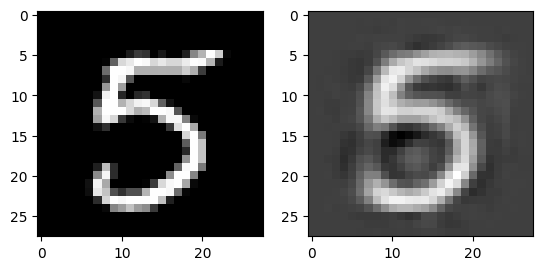

In [ ]:
import matplotlib.pyplot as plt

idx = 1
img = ds.x[idx]

input = torch.tensor(img, dtype=torch.float32).unsqueeze(dim=0)
input = input.to(device)
bottle_neck = encod(input/255.0)
output = decod(bottle_neck)

img2 = output.squeeze(0).detach().cpu().numpy().reshape(28, 28)

plt.subplot(1, 2, 1)
plt.imshow(img.reshape(28, 28), cmap='gray')
plt.subplot(1, 2, 2)
plt.imshow(img2, cmap='gray')
plt.show()